# 04 — LSTM Model

Train a PyTorch LSTM forecaster on a 10-year window of PJME load and predict the **same final 720 hours** that the SARIMA notebook predicted, so MAE/RMSE numbers are directly comparable.

Inputs: `data/raw/PJME_hourly.csv` (re-split here, since the LSTM uses a longer training window than SARIMA's 2-year split saved by notebook 02)

Outputs: `models/lstm_pjme.pt`, `results/figures/lstm_*.png`, appended LSTM record in `results/metrics.json`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_CSV = PROJECT_ROOT / 'data' / 'raw' / 'PJME_hourly.csv'
MODELS = PROJECT_ROOT / 'models'
FIGS = PROJECT_ROOT / 'results' / 'figures'
METRICS = PROJECT_ROOT / 'results' / 'metrics.json'
for d in (MODELS, FIGS):
    d.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

from src.data_loader import load_pjme
from src.preprocessing import ensure_hourly
from src.feature_engineering import build_lstm_features
from src.lstm_model import (
    INPUT_LEN, OUTPUT_LEN, TARGET_COL, TrainConfig,
    train_lstm, forecast, save_model,
)
from src.evaluation import mae, rmse, plot_forecast, append_metrics

## Load, clean, build features

In [2]:
raw = load_pjme(RAW_CSV)
clean = ensure_hourly(raw)[[TARGET_COL]]
features = build_lstm_features(clean, target=TARGET_COL)
print(f'Features: {features.shape}  (rows, cols)')
print('Columns:', list(features.columns))

Features: (145224, 9)  (rows, cols)
Columns: ['PJME_MW', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'PJME_MW_lag_24', 'PJME_MW_lag_168']


## Split: 10-year train, ~6-month val, last 720h test

Test set is the **same final 720 hours** that the SARIMA notebook used.

In [3]:
TEST_HOURS = OUTPUT_LEN              # 720
VAL_HOURS = 24 * 30 * 6              # ~6 months
TRAIN_HOURS = 24 * 365 * 10          # ~10 years

test_df = features.iloc[-TEST_HOURS:]
val_df = features.iloc[-(TEST_HOURS + VAL_HOURS):-TEST_HOURS]
train_df = features.iloc[-(TEST_HOURS + VAL_HOURS + TRAIN_HOURS):-(TEST_HOURS + VAL_HOURS)]

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name:5s}  rows={len(df):>6,}  {df.index.min()}  ->  {df.index.max()}')

train  rows=87,600  2008-01-08 01:00:00  ->  2018-01-05 00:00:00
val    rows= 4,320  2018-01-05 01:00:00  ->  2018-07-04 00:00:00
test   rows=   720  2018-07-04 01:00:00  ->  2018-08-03 00:00:00


## Scale (fit on train only — no leakage)

Cyclical features are already in `[-1, 1]`, but MinMax-scaling everything to `[0, 1]` keeps the LSTM input numerically clean.

In [4]:
scaler = MinMaxScaler().fit(train_df.values)
train_arr = scaler.transform(train_df.values)
val_arr = scaler.transform(val_df.values)
test_arr = scaler.transform(test_df.values)

# Keep target-column scale parameters for inverse-transforming forecasts
target_min = scaler.data_min_[0]
target_range = scaler.data_max_[0] - target_min
print(f'Target {TARGET_COL}: min={target_min:.1f}  range={target_range:.1f}')

Target PJME_MW: min=14544.0  range=47102.0


## Train

Stacked LSTM (2 layers, hidden=64) → Dense(720). Direct multi-step output. Adam + MSE + early stopping on validation loss.

In [5]:
cfg = TrainConfig()
print('Device:', cfg.device)
model, history = train_lstm(train_arr, val_arr, cfg)

Device: mps


epoch 01  train=0.02136  val=0.02953


epoch 02  train=0.00806  val=0.02255


epoch 03  train=0.00704  val=0.01984


epoch 04  train=0.00655  val=0.01873


...

epoch 10  train=0.00555  val=0.01163


epoch 11  train=0.00537  val=0.01033


epoch 12  train=0.00526  val=0.01111


epoch 13  train=0.00518  val=0.01123


epoch 14  train=0.00512  val=0.01209
early stopping at epoch 14 (no improvement for 5 epochs)


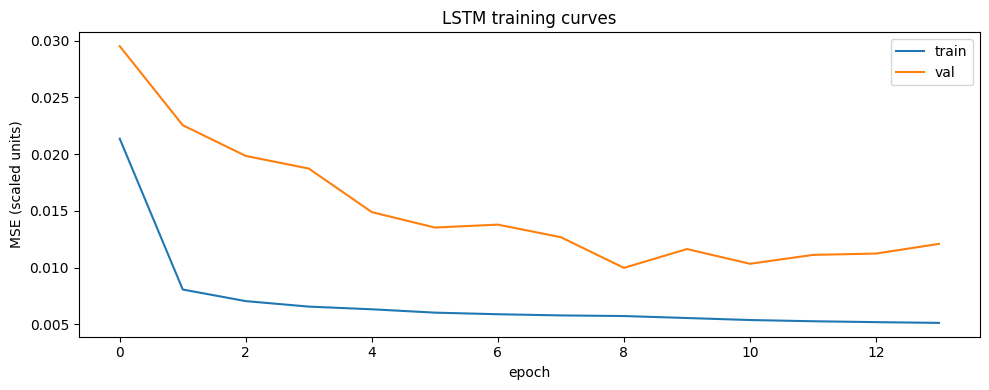

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['train_loss'], label='train')
ax.plot(history['val_loss'], label='val')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE (scaled units)'); ax.set_title('LSTM training curves')
ax.legend(); fig.tight_layout()
fig.savefig(FIGS / 'lstm_training_curves.png', dpi=120)

## Forecast the held-out 720 hours

Input window = the **last 168 hours of the validation set** (the most recent observations available before the test period). The model emits 720 forecast values in a single forward pass.

In [7]:
input_window = val_arr[-INPUT_LEN:]
scaled_pred = forecast(model, input_window, device=cfg.device)
predictions = scaled_pred * target_range + target_min   # inverse scale
predictions = pd.Series(predictions, index=test_df.index, name='forecast')

## Evaluate against the held-out test

In [8]:
actual = test_df[TARGET_COL]
metrics = {
    'MAE': mae(actual, predictions),
    'RMSE': rmse(actual, predictions),
    'epochs_run': len(history['train_loss']),
    'input_len': cfg.input_len,
    'output_len': cfg.output_len,
    'hidden_size': cfg.hidden_size,
    'num_layers': cfg.num_layers,
    'device': cfg.device,
}
print(metrics)

{'MAE': 4995.543111018629, 'RMSE': 6022.560727236748, 'epochs_run': 14, 'input_len': 168, 'output_len': 720, 'hidden_size': 64, 'num_layers': 2, 'device': 'mps'}


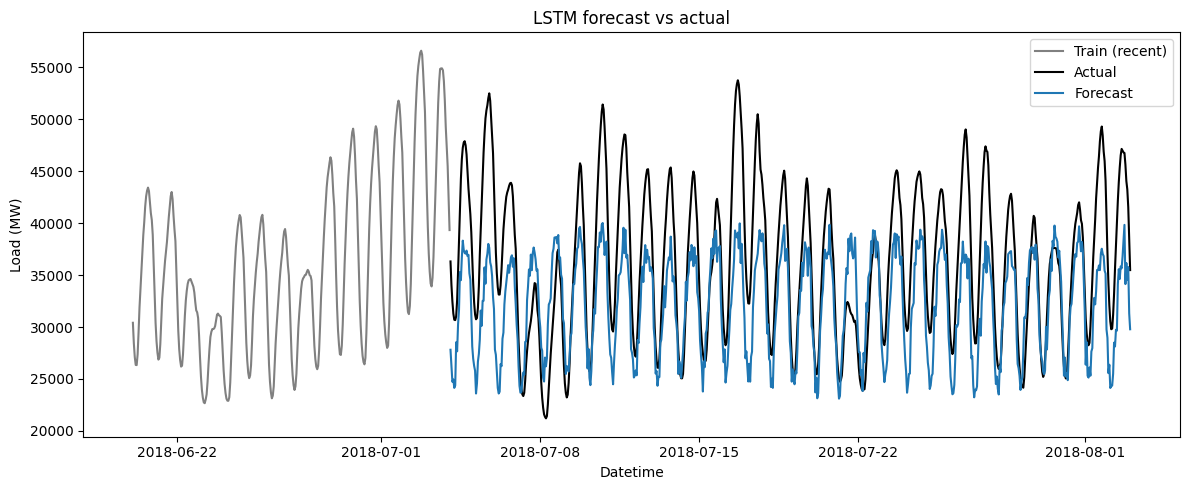

In [9]:
fig = plot_forecast(
    train_tail=val_df[TARGET_COL].iloc[-24*14:],   # last 14 days of val for context
    test=actual,
    point_forecast=predictions,
    conf_int=None,
    title='LSTM forecast vs actual',
)
fig.savefig(FIGS / 'lstm_forecast.png', dpi=120)

## Persist model + metrics

In [10]:
save_model(model, MODELS / 'lstm_pjme.pt')
append_metrics(METRICS, model='LSTM', region='PJME', horizon=len(test_df), metrics=metrics)
print('Wrote model state_dict and appended metrics record.')

Wrote model state_dict and appended metrics record.


## SARIMA vs LSTM comparison

In [11]:
import json
records = json.loads(METRICS.read_text())
comparison = pd.DataFrame([
    {'model': r['model'], 'MAE': r['MAE'], 'RMSE': r['RMSE'], 'horizon': r['horizon']}
    for r in records
])
comparison

,model,MAE,RMSE,horizon
0,SARIMA,11661.503186,12932.369325,720
1,LSTM,4995.543111,6022.560727,720
